# 🏢 HR Employee Data — Cleaning & Insights
> **Input:** `Employees.xlsx` — 689 employees across 5 countries and 20 departments  
> **Output:** Cleaned dataframe + full EDA insights + Power BI-ready Excel export

---

In [ ]:
pip install matplotlib
!pip install seaborn
!pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.8-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 10.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.4 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2e3250',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlepad':    12,
})

PALETTE = ['#4e9af1','#f97b6b','#50c878','#ffd166','#c77dff','#06d6a0','#f4a261','#a8dadc']
print("✅ Libraries loaded")

✅ Libraries loaded


## 1. Load Data

In [8]:
INPUT_FILE = 'Employees.xlsx'   # ← change path if needed

df_raw = pd.read_excel(INPUT_FILE)
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (689, 15)


,No,First Name,Last Name,Gender,Start Date,Years,Department,Country,Center,Monthly Salary,Annual Salary,Job Rate,Sick Leaves,Unpaid Leaves,Overtime Hours
0,1,Ghadir,Hmshw,Male,2018-04-04,2,Quality Control,Egypt,West,1560,18720,3.0,1,0,183
1,2,Omar,Hishan,Male,2020-05-21,0,Quality Control,Saudi Arabia,West,3247,38964,1.0,0,5,198
2,3,Ailya,Sharaf,Female,2017-09-28,3,Major Mfg Projects,Saudi Arabia,West,2506,30072,2.0,0,3,192
3,4,Lwiy,Qbany,Male,2018-08-14,2,Manufacturing,United Arab Emirates,Main,1828,21936,3.0,0,0,7
4,5,Ahmad,Bikri,Male,2020-03-11,0,Manufacturing,Egypt,Main,970,11640,5.0,0,5,121


## 2. Data Quality Check

In [9]:
print("── Nulls ──────────────────────────────")
print(df_raw.isnull().sum())
print(f"\n── Duplicates: {df_raw.duplicated().sum()} ──")
print("\n── Dtypes ─────────────────────────────")
print(df_raw.dtypes)
print("\n── Basic Stats ────────────────────────")
df_raw.describe()

── Nulls ──────────────────────────────
No                0
First Name        0
Last Name         0
Gender            0
Start Date        0
Years             0
Department        0
Country           0
Center            0
Monthly Salary    0
Annual Salary     0
Job Rate          0
Sick Leaves       0
Unpaid Leaves     0
Overtime Hours    0
dtype: int64

── Duplicates: 0 ──

── Dtypes ─────────────────────────────
No                         int64
First Name                   str
Last Name                    str
Gender                       str
Start Date        datetime64[us]
Years                      int64
Department                   str
Country                      str
Center                       str
Monthly Salary             int64
Annual Salary              int64
Job Rate                 float64
Sick Leaves                int64
Unpaid Leaves              int64
Overtime Hours             int64
dtype: object

── Basic Stats ────────────────────────


,No,Start Date,Years,Monthly Salary,Annual Salary,Job Rate,Sick Leaves,Unpaid Leaves,Overtime Hours
count,689.000000,689,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000
mean,345.000000,2019-01-25 09:20:06.966618,1.476052,2068.201742,24818.420900,3.586357,1.609579,0.759071,13.702467
min,1.000000,2016-01-08 00:00:00,0.000000,703.000000,8436.000000,1.000000,0.000000,0.000000,0.000000
25%,173.000000,2018-04-05 00:00:00,1.000000,1436.000000,17232.000000,3.000000,0.000000,0.000000,3.000000
50%,345.000000,2019-04-03 00:00:00,1.000000,2077.000000,24924.000000,3.000000,0.000000,0.000000,7.000000
75%,517.000000,2019-12-22 00:00:00,2.000000,2682.000000,32184.000000,5.000000,3.000000,0.000000,10.000000
max,689.000000,2020-12-29 00:00:00,5.000000,3450.000000,41400.000000,5.000000,6.000000,6.000000,198.000000
std,199.041453,NaN,1.190963,763.289240,9159.470878,1.350125,2.196051,1.647764,25.692049


## 3. Clean the Data

**Steps applied:**
- Normalize names → Title Case
- Add `Full Name` column
- Recalculate `Tenure Years` from `Start Date` (fixes ~30 borderline records)
- Add `Salary Band`, `Job Level`, leave flags, overtime flag

In [10]:
df = df_raw.copy()

# Names
df['First Name'] = df['First Name'].str.strip().str.title()
df['Last Name']  = df['Last Name'].str.strip().str.title()
df['Full Name']  = df['First Name'] + ' ' + df['Last Name']

# Date & tenure
df['Start Date']   = pd.to_datetime(df['Start Date'])
REF_DATE           = pd.Timestamp('2021-01-01')
df['Tenure Years'] = ((REF_DATE - df['Start Date']).dt.days / 365.25).round().astype(int)

# Salary band
bins   = [0, 1000, 1500, 2000, 2500, 9999]
labels = ['<1K', '1K-1.5K', '1.5K-2K', '2K-2.5K', '>2.5K']
df['Salary Band'] = pd.cut(df['Monthly Salary'], bins=bins, labels=labels).astype(str)

# Job level
rate_map = {1.0:'Junior', 2.0:'Mid', 3.0:'Senior', 4.5:'Lead', 5.0:'Principal'}
df['Job Level'] = df['Job Rate'].map(rate_map)

# Flags
df['Has Sick Leave']   = df['Sick Leaves']   > 0
df['Has Unpaid Leave'] = df['Unpaid Leaves']  > 0
df['High Overtime']    = df['Overtime Hours'] > 50

clean_cols = [
    'No','Full Name','First Name','Last Name','Gender','Start Date','Tenure Years',
    'Department','Country','Center','Monthly Salary','Annual Salary','Salary Band',
    'Job Rate','Job Level','Sick Leaves','Unpaid Leaves','Overtime Hours',
    'Has Sick Leave','Has Unpaid Leave','High Overtime'
]
df_clean = df[clean_cols].copy()
print(f"✅ Clean dataframe: {df_clean.shape}")
df_clean.head()

✅ Clean dataframe: (689, 21)


,No,Full Name,First Name,Last Name,Gender,Start Date,Tenure Years,Department,Country,Center,...,Annual Salary,Salary Band,Job Rate,Job Level,Sick Leaves,Unpaid Leaves,Overtime Hours,Has Sick Leave,Has Unpaid Leave,High Overtime
0,1,Ghadir Hmshw,Ghadir,Hmshw,Male,2018-04-04,3,Quality Control,Egypt,West,...,18720,1.5K-2K,3.0,Senior,1,0,183,True,False,True
1,2,Omar Hishan,Omar,Hishan,Male,2020-05-21,1,Quality Control,Saudi Arabia,West,...,38964,>2.5K,1.0,Junior,0,5,198,False,True,True
2,3,Ailya Sharaf,Ailya,Sharaf,Female,2017-09-28,3,Major Mfg Projects,Saudi Arabia,West,...,30072,>2.5K,2.0,Mid,0,3,192,False,True,True
3,4,Lwiy Qbany,Lwiy,Qbany,Male,2018-08-14,2,Manufacturing,United Arab Emirates,Main,...,21936,1.5K-2K,3.0,Senior,0,0,7,False,False,False
4,5,Ahmad Bikri,Ahmad,Bikri,Male,2020-03-11,1,Manufacturing,Egypt,Main,...,11640,<1K,5.0,Principal,0,5,121,False,True,True


## 4. Key Metrics Summary

In [11]:
total        = len(df_clean)
avg_salary   = df_clean['Monthly Salary'].mean()
avg_tenure   = df_clean['Tenure Years'].mean()
sick_rate    = df_clean['Has Sick Leave'].mean() * 100
unpaid_rate  = df_clean['Has Unpaid Leave'].mean() * 100
high_ot_rate = df_clean['High Overtime'].mean() * 100
gender_gap   = df_clean.groupby('Gender')['Monthly Salary'].mean()

print("=" * 45)
print(f"  Total Employees       : {total}")
print(f"  Avg Monthly Salary    : ${avg_salary:,.0f}")
print(f"  Avg Annual Cost       : ${avg_salary*12:,.0f}")
print(f"  Avg Tenure            : {avg_tenure:.1f} years")
print(f"  Sick Leave Rate       : {sick_rate:.1f}%")
print(f"  Unpaid Leave Rate     : {unpaid_rate:.1f}%")
print(f"  High Overtime (>50h)  : {high_ot_rate:.1f}%")
print("-" * 45)
for g, s in gender_gap.items():
    print(f"  Avg Salary ({g:6s})   : ${s:,.0f}")
print("=" * 45)

  Total Employees       : 689
  Avg Monthly Salary    : $2,068
  Avg Annual Cost       : $24,818
  Avg Tenure            : 1.9 years
  Sick Leave Rate       : 46.3%
  Unpaid Leave Rate     : 21.5%
  High Overtime (>50h)  : 7.5%
---------------------------------------------
  Avg Salary (Female)   : $2,059
  Avg Salary (Male  )   : $2,073


## 5. Workforce Composition

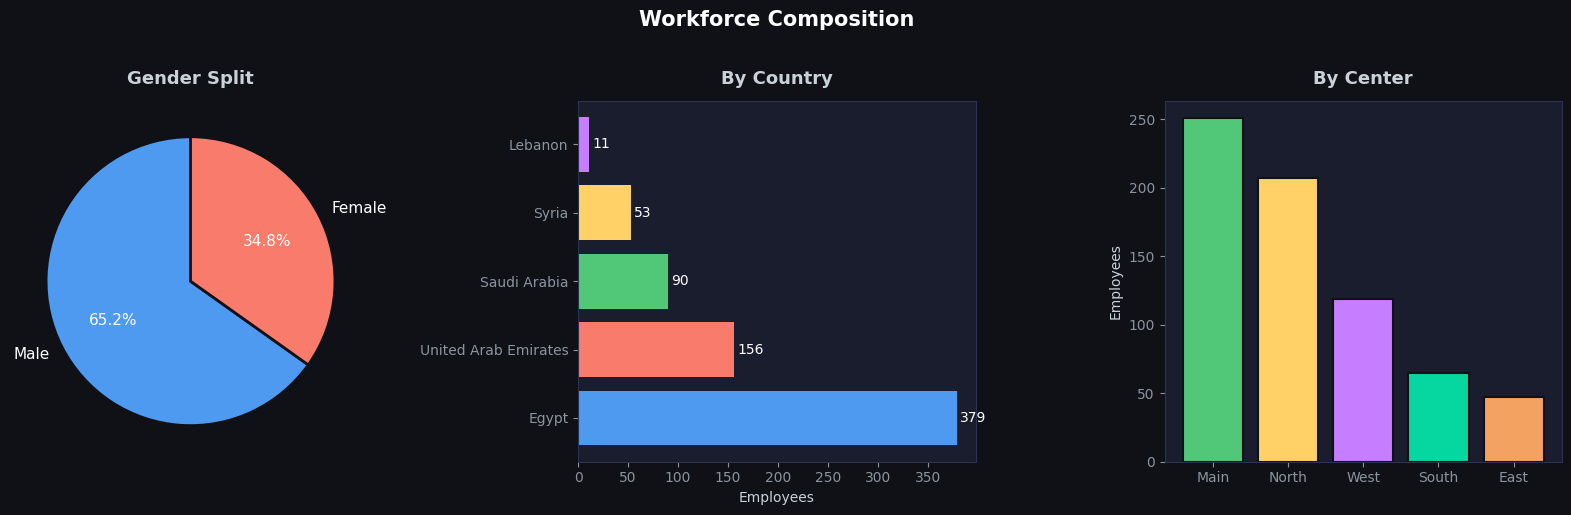

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Workforce Composition', fontsize=15, fontweight='bold', color='white', y=1.02)

# Gender
gender = df_clean['Gender'].value_counts()
axes[0].pie(gender, labels=gender.index, autopct='%1.1f%%',
            colors=['#4e9af1','#f97b6b'], startangle=90,
            wedgeprops={'edgecolor':'#0f1117','linewidth':2},
            textprops={'color':'white','fontsize':11})
axes[0].set_title('Gender Split')

# Country
country = df_clean['Country'].value_counts()
bars = axes[1].barh(country.index, country.values, color=PALETTE[:len(country)])
axes[1].set_xlabel('Employees')
axes[1].set_title('By Country')
for bar, val in zip(bars, country.values):
    axes[1].text(val + 3, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', color='white', fontsize=10)

# Center
center = df_clean['Center'].value_counts()
axes[2].bar(center.index, center.values, color=PALETTE[2:], edgecolor='#0f1117', linewidth=1.5)
axes[2].set_title('By Center')
axes[2].set_ylabel('Employees')

plt.tight_layout()
plt.show()

## 6. Department Analysis

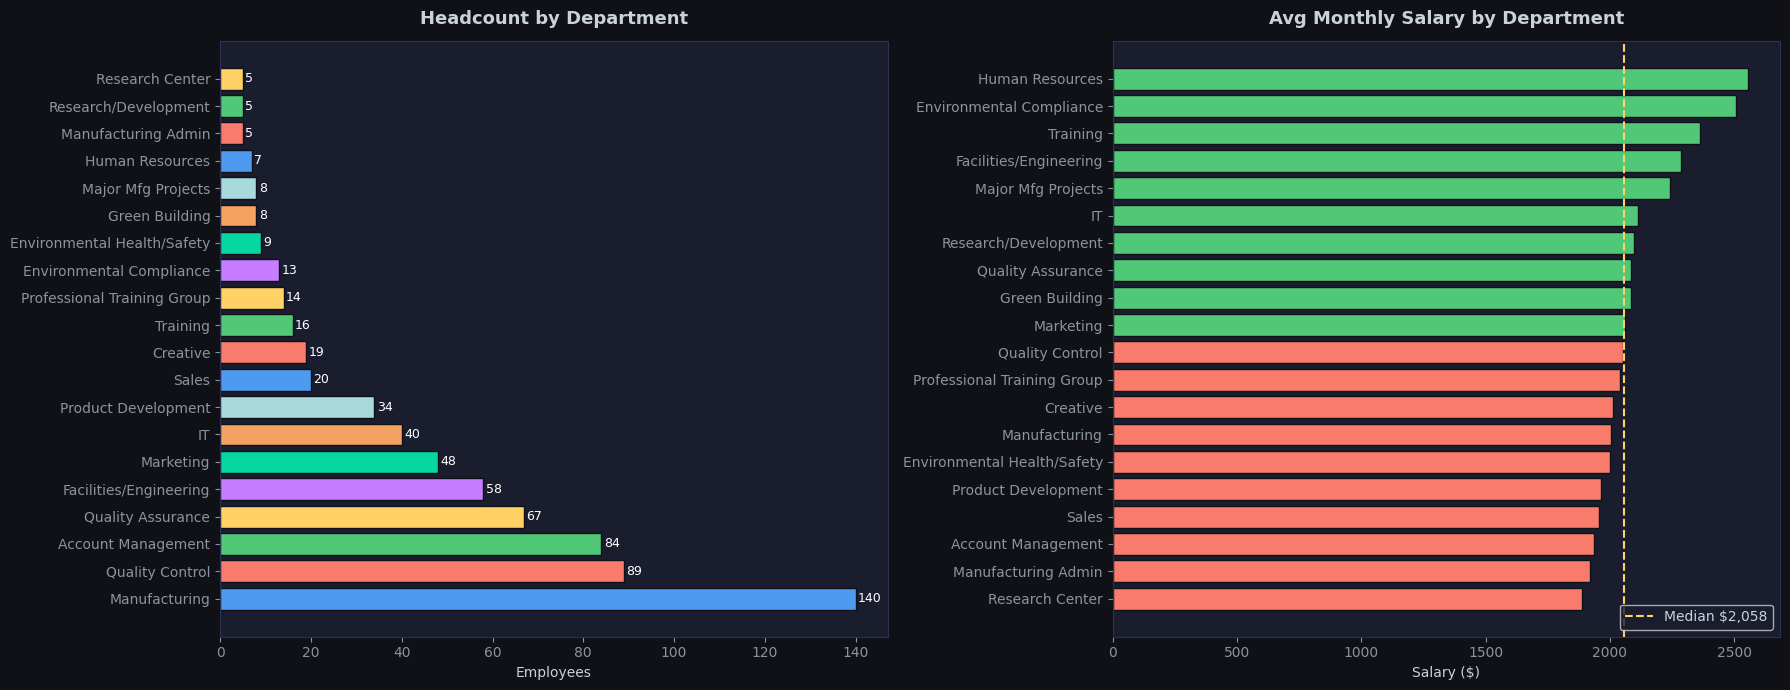


Department Summary Table:


,Count,Avg_Salary,Avg_OT,Sick_Pct,HighOT_Pct
Department,,,,,
Manufacturing,140,2004.600000,12.100000,0.400000,0.000000
Quality Control,89,2054.000000,19.100000,0.400000,0.100000
Account Management,84,1937.200000,15.000000,0.500000,0.100000
Quality Assurance,67,2083.900000,11.500000,0.500000,0.000000
Facilities/Engineering,58,2285.300000,10.400000,0.500000,0.000000
Marketing,48,2061.100000,6.900000,0.500000,0.000000
IT,40,2114.500000,13.100000,0.400000,0.100000
Product Development,34,1964.700000,6.400000,0.300000,0.000000
Sales,20,1956.400000,23.300000,0.300000,0.200000


In [13]:
dept_stats = df_clean.groupby('Department').agg(
    Count       =('No', 'count'),
    Avg_Salary  =('Monthly Salary', 'mean'),
    Avg_OT      =('Overtime Hours', 'mean'),
    Sick_Pct    =('Has Sick Leave', 'mean'),
    HighOT_Pct  =('High Overtime', 'mean'),
).round(1).sort_values('Count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0f1117')

# Headcount
colors_hc = [PALETTE[i % len(PALETTE)] for i in range(len(dept_stats))]
axes[0].barh(dept_stats.index, dept_stats['Count'], color=colors_hc, edgecolor='#0f1117')
axes[0].set_title('Headcount by Department')
axes[0].set_xlabel('Employees')
for i, (idx, row) in enumerate(dept_stats.iterrows()):
    axes[0].text(row['Count'] + 0.5, i, str(int(row['Count'])), va='center', fontsize=9, color='white')

# Avg Salary
dept_sal = dept_stats['Avg_Salary'].sort_values(ascending=True)
colors_sal = ['#50c878' if s >= dept_stats['Avg_Salary'].median() else '#f97b6b' for s in dept_sal]
axes[1].barh(dept_sal.index, dept_sal.values, color=colors_sal, edgecolor='#0f1117')
axes[1].set_title('Avg Monthly Salary by Department')
axes[1].set_xlabel('Salary ($)')
median_sal = dept_stats['Avg_Salary'].median()
axes[1].axvline(median_sal, color='#ffd166', linestyle='--', linewidth=1.5, label=f'Median ${median_sal:,.0f}')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("\nDepartment Summary Table:")
dept_stats.style.background_gradient(cmap='Blues', subset=['Count','Avg_Salary','Avg_OT'])

## 7. Salary Deep Dive

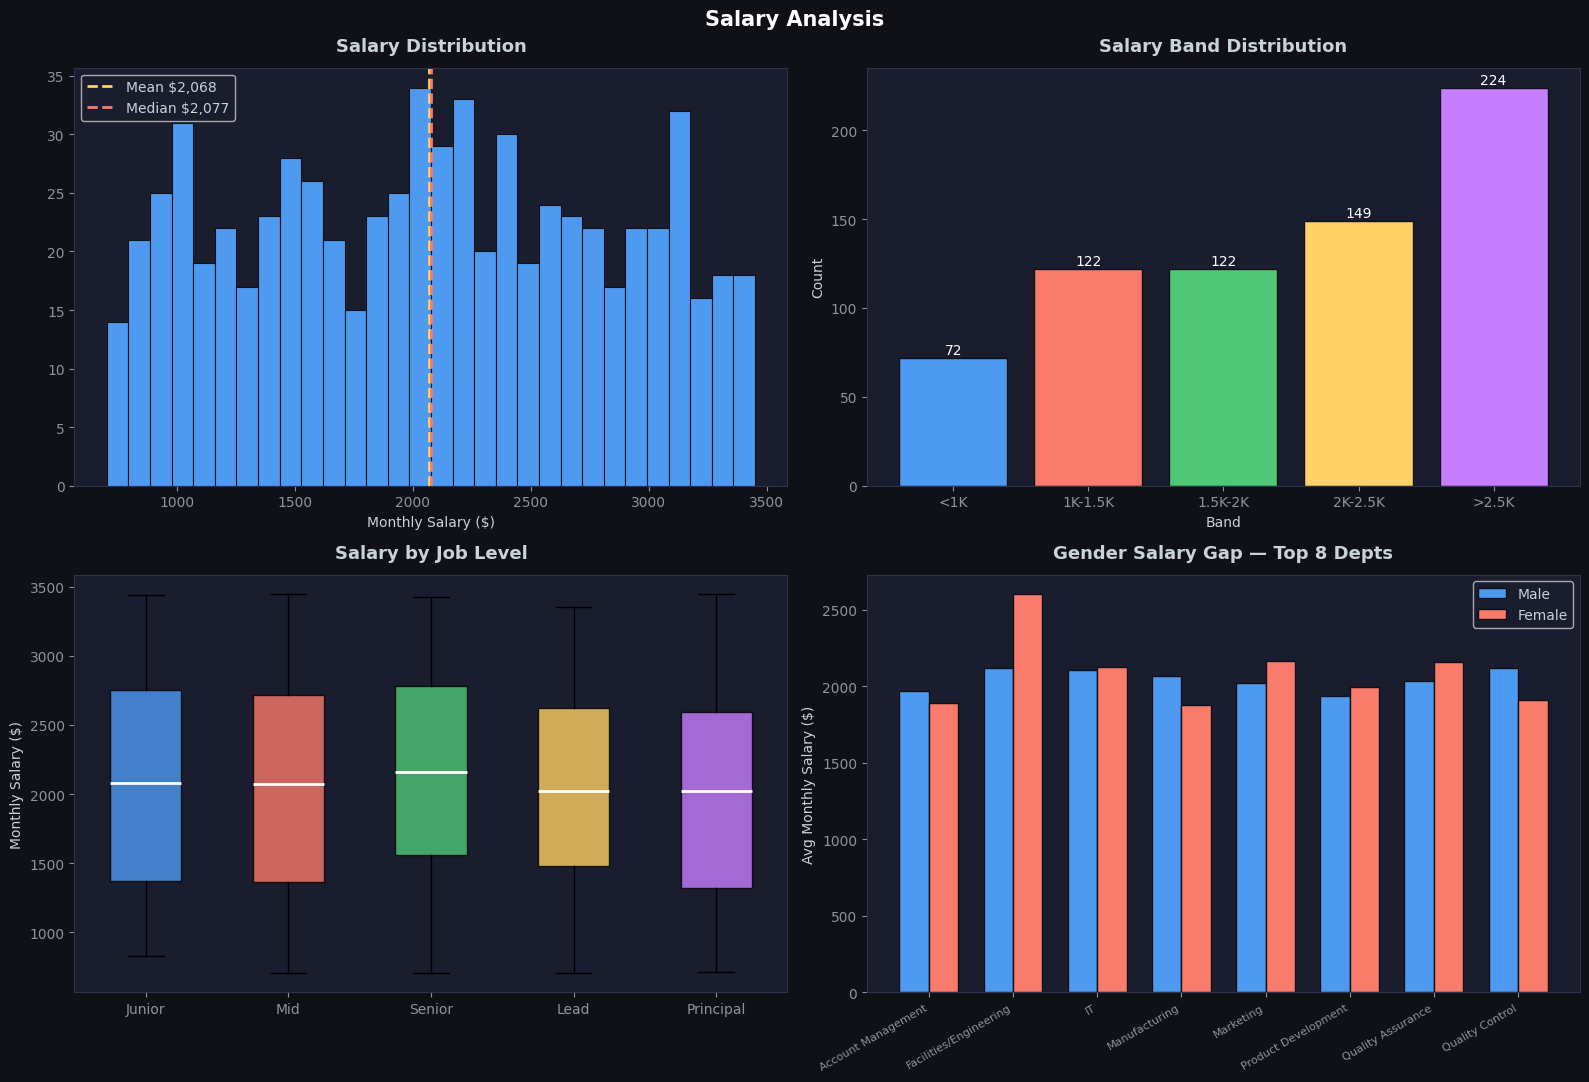

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Salary Analysis', fontsize=15, fontweight='bold', color='white')

# Distribution
axes[0,0].hist(df_clean['Monthly Salary'], bins=30, color='#4e9af1',
               edgecolor='#0f1117', linewidth=0.8)
axes[0,0].axvline(df_clean['Monthly Salary'].mean(), color='#ffd166',
                  linestyle='--', linewidth=2, label=f"Mean ${df_clean['Monthly Salary'].mean():,.0f}")
axes[0,0].axvline(df_clean['Monthly Salary'].median(), color='#f97b6b',
                  linestyle='--', linewidth=2, label=f"Median ${df_clean['Monthly Salary'].median():,.0f}")
axes[0,0].set_title('Salary Distribution')
axes[0,0].set_xlabel('Monthly Salary ($)')
axes[0,0].legend()

# Salary Band
band_order = ['<1K','1K-1.5K','1.5K-2K','2K-2.5K','>2.5K']
band_counts = df_clean['Salary Band'].value_counts().reindex(band_order)
axes[0,1].bar(band_counts.index, band_counts.values, color=PALETTE, edgecolor='#0f1117')
axes[0,1].set_title('Salary Band Distribution')
axes[0,1].set_xlabel('Band')
axes[0,1].set_ylabel('Count')
for i, v in enumerate(band_counts.values):
    axes[0,1].text(i, v + 2, str(v), ha='center', color='white', fontsize=10)

# Job Level vs Salary
level_order = ['Junior','Mid','Senior','Lead','Principal']
level_data = [df_clean[df_clean['Job Level']==lvl]['Monthly Salary'].dropna() for lvl in level_order]
bp = axes[1,0].boxplot(level_data, labels=level_order, patch_artist=True,
                        medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[1,0].set_title('Salary by Job Level')
axes[1,0].set_ylabel('Monthly Salary ($)')

# Gender salary by department (top 8)
top8 = dept_stats.nlargest(8, 'Count').index
pivot = df_clean[df_clean['Department'].isin(top8)].groupby(['Department','Gender'])['Monthly Salary'].mean().unstack()
x = np.arange(len(pivot))
w = 0.35
axes[1,1].bar(x - w/2, pivot.get('Male',   pd.Series([0]*len(pivot))),
              w, label='Male',   color='#4e9af1', edgecolor='#0f1117')
axes[1,1].bar(x + w/2, pivot.get('Female', pd.Series([0]*len(pivot))),
              w, label='Female', color='#f97b6b', edgecolor='#0f1117')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(pivot.index, rotation=30, ha='right', fontsize=8)
axes[1,1].set_title('Gender Salary Gap — Top 8 Depts')
axes[1,1].set_ylabel('Avg Monthly Salary ($)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

## 8. Tenure & Retention Insights

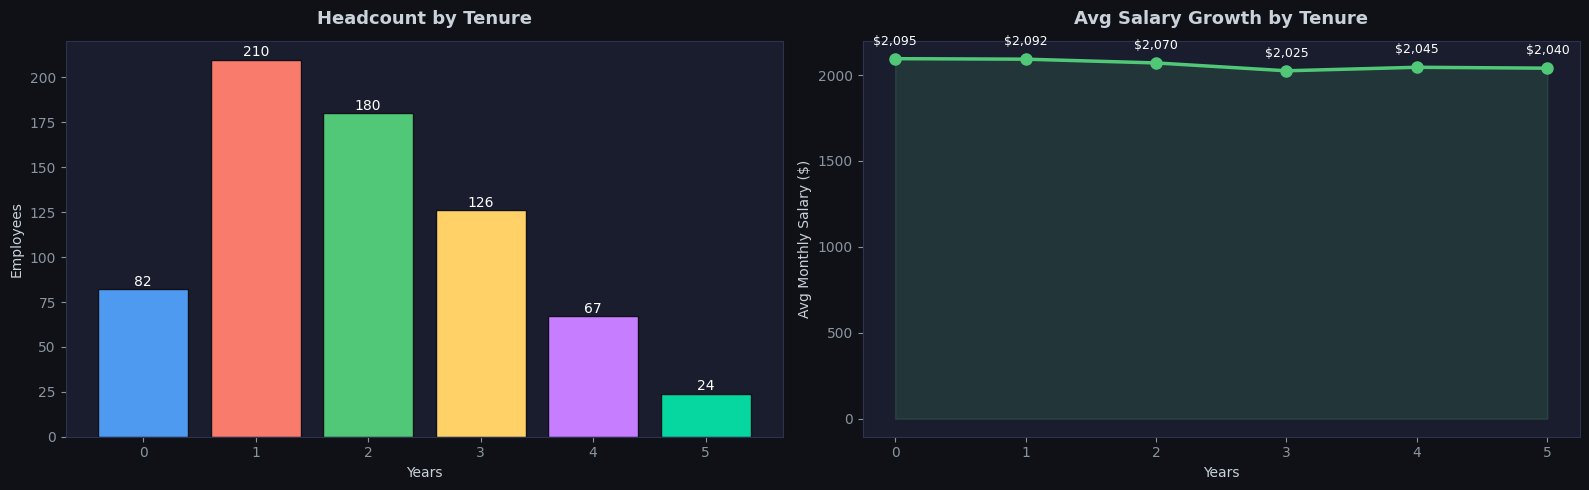

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# Tenure distribution
tenure_counts = df_clean['Tenure Years'].value_counts().sort_index()
axes[0].bar(tenure_counts.index.astype(str), tenure_counts.values,
            color=PALETTE, edgecolor='#0f1117')
axes[0].set_title('Headcount by Tenure')
axes[0].set_xlabel('Years')
axes[0].set_ylabel('Employees')
for i, v in enumerate(tenure_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', color='white', fontsize=10)

# Salary by tenure
tenure_sal = df_clean.groupby('Tenure Years')['Monthly Salary'].mean()
axes[1].plot(tenure_sal.index, tenure_sal.values, marker='o', color='#50c878',
             linewidth=2.5, markersize=8)
axes[1].fill_between(tenure_sal.index, tenure_sal.values, alpha=0.15, color='#50c878')
axes[1].set_title('Avg Salary Growth by Tenure')
axes[1].set_xlabel('Years')
axes[1].set_ylabel('Avg Monthly Salary ($)')
for x, y in zip(tenure_sal.index, tenure_sal.values):
    axes[1].annotate(f'${y:,.0f}', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9, color='white')

plt.tight_layout()
plt.show()

## 9. Leave & Overtime Analysis

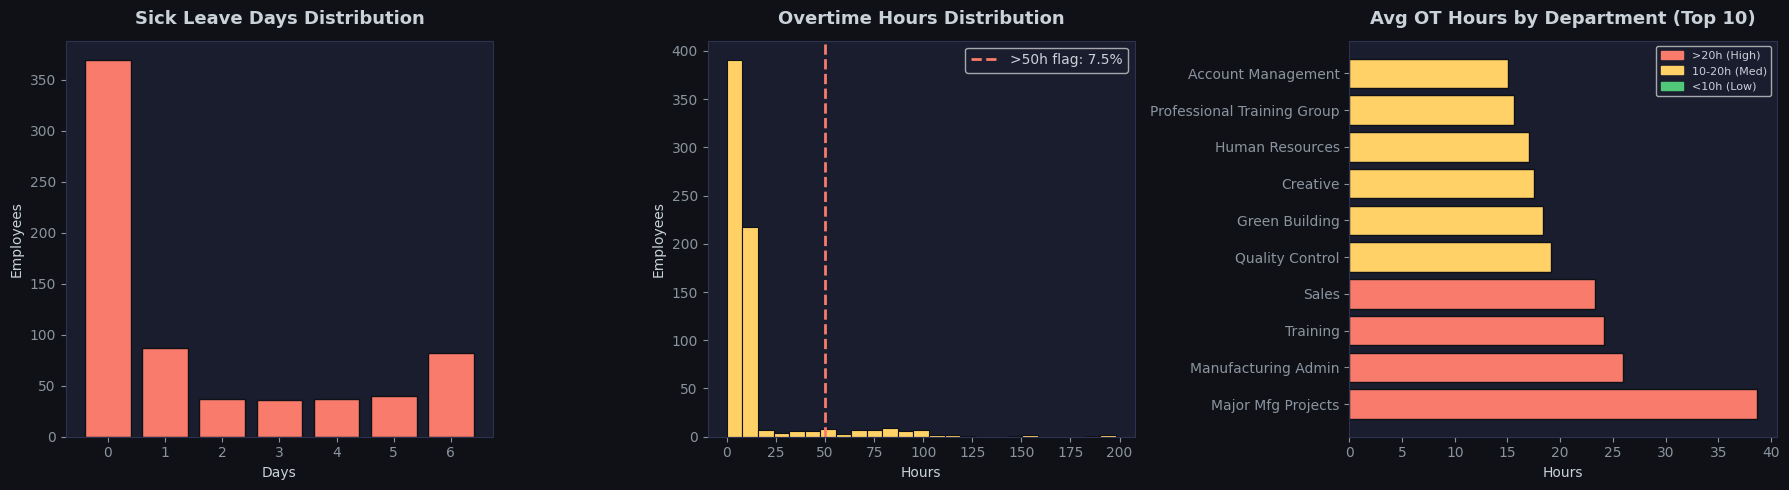

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')

# Sick leaves distribution
sick_counts = df_clean['Sick Leaves'].value_counts().sort_index()
axes[0].bar(sick_counts.index.astype(str), sick_counts.values,
            color='#f97b6b', edgecolor='#0f1117')
axes[0].set_title('Sick Leave Days Distribution')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Employees')

# Overtime distribution (capped at 60 for readability)
ot_data = df_clean['Overtime Hours'].clip(upper=200)
axes[1].hist(ot_data, bins=25, color='#ffd166', edgecolor='#0f1117', linewidth=0.8)
axes[1].set_title('Overtime Hours Distribution')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Employees')
pct = (df_clean['Overtime Hours'] > 50).mean() * 100
axes[1].axvline(50, color='#f97b6b', linestyle='--', linewidth=2,
                label=f'>{50}h flag: {pct:.1f}%')
axes[1].legend()

# Overtime by department (top 10)
ot_by_dept = df_clean.groupby('Department')['Overtime Hours'].mean().sort_values(ascending=False).head(10)
colors_ot = ['#f97b6b' if v > 20 else ('#ffd166' if v > 10 else '#50c878') for v in ot_by_dept]
axes[2].barh(ot_by_dept.index, ot_by_dept.values, color=colors_ot, edgecolor='#0f1117')
axes[2].set_title('Avg OT Hours by Department (Top 10)')
axes[2].set_xlabel('Hours')
red_p   = mpatches.Patch(color='#f97b6b', label='>20h (High)')
amber_p = mpatches.Patch(color='#ffd166', label='10-20h (Med)')
green_p = mpatches.Patch(color='#50c878', label='<10h (Low)')
axes[2].legend(handles=[red_p, amber_p, green_p], fontsize=8)

plt.tight_layout()
plt.show()

## 10. Correlation Heatmap

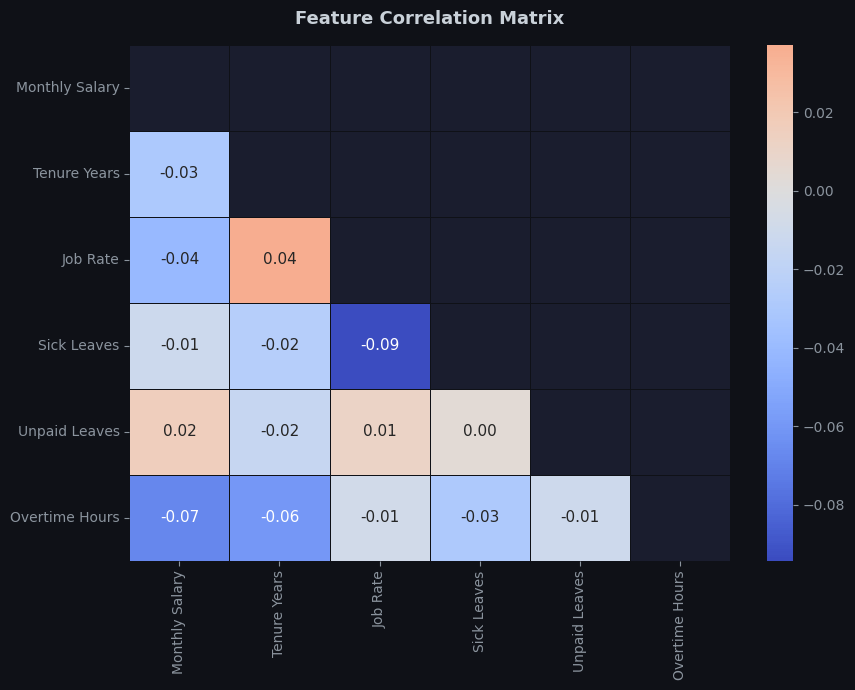

In [17]:
numeric_cols = ['Monthly Salary','Tenure Years','Job Rate','Sick Leaves',
                'Unpaid Leaves','Overtime Hours']
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', ax=ax,
            cmap='coolwarm', center=0, linewidths=0.5,
            linecolor='#0f1117', annot_kws={'size':11})
ax.set_title('Feature Correlation Matrix', pad=15)
plt.tight_layout()
plt.show()

## 11. Insight Summary

In [18]:
gender_dist  = df_clean['Gender'].value_counts()
gender_sal   = df_clean.groupby('Gender')['Monthly Salary'].mean()
top_dept     = dept_stats['Count'].idxmax()
top_ot_dept  = dept_stats['Avg_OT'].idxmax()
top_sal_dept = dept_stats['Avg_Salary'].idxmax()
top_country  = df_clean['Country'].value_counts().idxmax()

gap = abs(gender_sal.get('Male',0) - gender_sal.get('Female',0))

insights = [
    f"👥  Gender: {gender_dist.get('Male',0)} Male ({gender_dist.get('Male',0)/total*100:.0f}%) "
    f"/ {gender_dist.get('Female',0)} Female ({gender_dist.get('Female',0)/total*100:.0f}%)",
    f"💰  Avg Monthly Salary: ${avg_salary:,.0f}  |  Avg Annual: ${avg_salary*12:,.0f}",
    f"⚖️   Gender Pay Gap: ${gap:,.0f}/mo  ({gap/avg_salary*100:.1f}% of avg salary)",
    f"🏢  Largest Department: {top_dept} ({int(dept_stats.loc[top_dept,'Count'])} employees)",
    f"💸  Highest Paying Dept: {top_sal_dept} (${dept_stats.loc[top_sal_dept,'Avg_Salary']:,.0f}/mo)",
    f"⏱️   Most Overtime Dept: {top_ot_dept} ({dept_stats.loc[top_ot_dept,'Avg_OT']:.1f} avg hrs)",
    f"🌍  Largest Country: {top_country} ({df_clean['Country'].value_counts()[top_country]} employees)",
    f"📅  Avg Tenure: {avg_tenure:.1f} years",
    f"🤒  Sick Leave Rate: {sick_rate:.1f}% of workforce",
    f"🔴  High Overtime (>50h): {high_ot_rate:.1f}% of workforce",
]

print("\n" + "=" * 60)
print("  KEY INSIGHTS")
print("=" * 60)
for insight in insights:
    print(f"  {insight}")
print("=" * 60)


  KEY INSIGHTS
  👥  Gender: 449 Male (65%) / 240 Female (35%)
  💰  Avg Monthly Salary: $2,068  |  Avg Annual: $24,818
  ⚖️   Gender Pay Gap: $14/mo  (0.7% of avg salary)
  🏢  Largest Department: Manufacturing (140 employees)
  💸  Highest Paying Dept: Human Resources ($2,556/mo)
  ⏱️   Most Overtime Dept: Major Mfg Projects (38.6 avg hrs)
  🌍  Largest Country: Egypt (379 employees)
  📅  Avg Tenure: 1.9 years
  🤒  Sick Leave Rate: 46.3% of workforce
  🔴  High Overtime (>50h): 7.5% of workforce


## 12. Export Cleaned Data

In [19]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

OUTPUT_FILE = 'Employees_Cleaned.xlsx'

# ── Styles
NAVY   = PatternFill('solid', start_color='1F3864')
BLUE   = PatternFill('solid', start_color='2E75B6')
ACCENT = PatternFill('solid', start_color='EBF3FB')
WHITE  = PatternFill('solid', start_color='FFFFFF')

thin = Side(style='thin', color='B0C4DE')
bord = Border(left=thin, right=thin, top=thin, bottom=thin)

def sh(c, fill=NAVY, size=10, bold=True, color='FFFFFF'):
    c.fill = fill
    c.font = Font(name='Arial', bold=bold, size=size, color=color)
    c.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    c.border = bord

def sc(c, fill=WHITE, bold=False, align='left'):
    c.fill = fill
    c.font = Font(name='Arial', bold=bold, size=10)
    c.alignment = Alignment(horizontal=align, vertical='center', wrap_text=True)
    c.border = bord

wb = openpyxl.Workbook()

# ── Sheet 1: Clean Data
ws1 = wb.active; ws1.title = 'Clean Data'
for ci, h in enumerate(df_clean.columns, 1):
    sh(ws1.cell(1, ci, h))
ws1.row_dimensions[1].height = 28
for ri, row in enumerate(df_clean.itertuples(index=False), 2):
    for ci, val in enumerate(row, 1):
        if isinstance(val, bool): val = 'Yes' if val else 'No'
        sc(ws1.cell(ri, ci, val), fill=ACCENT if ri%2==0 else WHITE)
col_widths = [5,22,12,12,8,14,10,22,16,8,14,14,10,8,10,10,12,14,12,14,12]
for ci, w in enumerate(col_widths[:len(df_clean.columns)], 1):
    ws1.column_dimensions[get_column_letter(ci)].width = w
ws1.freeze_panes = 'A2'

# ── Sheet 2: Department Summary
ws2 = wb.create_sheet('Dept Summary')
dept_export = df_clean.groupby('Department').agg(
    Employees=('No','count'),
    Avg_Monthly_Salary=('Monthly Salary', lambda x: round(x.mean(),0)),
    Total_Annual_Cost=('Annual Salary','sum'),
    Avg_OT_Hours=('Overtime Hours', lambda x: round(x.mean(),1)),
    Sick_Leave_Count=('Has Sick Leave','sum'),
    High_OT_Count=('High Overtime','sum'),
).reset_index()
dept_export.columns = ['Department','Employees','Avg Monthly Salary ($)',
                        'Total Annual Cost ($)','Avg OT Hours','Sick Leave #','High OT #']
for ci, h in enumerate(dept_export.columns, 1):
    sh(ws2.cell(1, ci, h), fill=BLUE)
    ws2.column_dimensions[get_column_letter(ci)].width = 22
for ri, row in enumerate(dept_export.itertuples(index=False), 2):
    for ci, val in enumerate(row, 1):
        sc(ws2.cell(ri, ci, val), fill=ACCENT if ri%2==0 else WHITE, align='center')

# ── Sheet 3: Country Summary
ws3 = wb.create_sheet('Country Summary')
country_export = df_clean.groupby('Country').agg(
    Employees=('No','count'),
    Avg_Salary=('Monthly Salary', lambda x: round(x.mean(),0)),
    Avg_OT=('Overtime Hours', lambda x: round(x.mean(),1)),
).reset_index()
country_export.columns = ['Country','Employees','Avg Monthly Salary ($)','Avg OT Hours']
for ci, h in enumerate(country_export.columns, 1):
    sh(ws3.cell(1, ci, h), fill=BLUE)
    ws3.column_dimensions[get_column_letter(ci)].width = 22
for ri, row in enumerate(country_export.itertuples(index=False), 2):
    for ci, val in enumerate(row, 1):
        sc(ws3.cell(ri, ci, val), fill=ACCENT if ri%2==0 else WHITE, align='center')

wb.save(OUTPUT_FILE)
print(f"✅ Saved → {OUTPUT_FILE}")
print(f"   Sheets: Clean Data, Dept Summary, Country Summary")

✅ Saved → Employees_Cleaned.xlsx
   Sheets: Clean Data, Dept Summary, Country Summary
